# 04 — Defining operational churn

**Goal:** compare 30-, 60-, and 90-day future inactivity outcomes for recently active
players, without label leakage or end-of-dataset censoring. This notebook establishes
eligibility and candidate targets only. It trains no models, creates no predictive
features beyond eligibility checks, and exports no ML dataset or processed files.
Figures are saved to `reports/figures/`; candidate labels remain in memory.

Day 3 found a median of 11 recorded activity days and completed inactivity P90/P95
of 22/60 full days. Many players returned after long spells. These are descriptive
full-period findings, not evidence that inactivity means permanent departure.
The 60-day target is a working hypothesis to evaluate rather than an assumed result.
Interpretations below come from this notebook's executed tables; revise them if inputs change.

## 1. Load, validate, and define true gaming activity

**A true gaming activity day requires `Bets > 0`.** Cleaning identified zero-Bets
rows with non-zero Winnings; these may reflect accounting transactions rather than
active play. Transaction presence alone therefore cannot establish that someone gambled.
Negative Winnings are documented accounting corrections and remain unchanged. All rows
stay in `daily` for future financial calculations; only the activity view is filtered.
The original Country, Language, and Gender codes remain unchanged.

Validate shapes, player coverage, unique keys, missingness, numeric values, and all date
ranges. Hash both inputs to verify that analysis never alters the cleaned CSVs.

In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display

project_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / 'data/processed/demographics_clean.csv').is_file()
    and (p / 'notebooks').is_dir()), None)
if project_root is None:
    raise FileNotFoundError('Run from the repository root or notebooks directory.')
inputs = [project_root / 'data/processed' / name for name in
          ['demographics_clean.csv', 'daily_activity_clean.csv']]
input_hashes = {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in inputs}
FIGURE_DIR = project_root / 'reports/figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
saved_figures, section_notes = [], {}
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 3)
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 180, 'font.size': 10,
    'axes.titlesize': 14, 'axes.labelsize': 11, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.facecolor': '#f8fafc', 'figure.facecolor': 'white'})
COLORS = {30: '#2563a6', 60: '#16857b', 90: '#a66b25'}
def save_show(fig, name):
    fig.savefig(FIGURE_DIR / name, bbox_inches='tight')
    saved_figures.append(name)
    plt.show()
    plt.close(fig)

demographics = pd.read_csv(inputs[0], dtype={c: 'int64' for c in
    ['UserID', 'Country', 'Language', 'Gender']})
daily = pd.read_csv(inputs[1], dtype={'UserID': 'int64', 'Bets': 'int64'},
                    float_precision='round_trip')
assert demographics.columns.tolist() == ['UserID', 'Country', 'Language', 'Gender',
                                         'RegDate', 'Fstcadate', 'Fstpdate']
assert daily.columns.tolist() == ['UserID', 'Date', 'Stake', 'Winnings', 'Bets']
assert demographics.shape == (4222, 7) and daily.shape == (98991, 5)
for col in ['RegDate', 'Fstcadate', 'Fstpdate']:
    demographics[col] = pd.to_datetime(demographics[col], format='%Y-%m-%d', errors='raise')
daily['Date'] = pd.to_datetime(daily['Date'], format='%Y-%m-%d', errors='raise')
assert demographics.UserID.is_unique
assert not daily.duplicated(['UserID', 'Date']).any()
assert set(demographics.UserID) == set(daily.UserID)
assert daily.UserID.nunique() == 4222
assert not demographics.isna().any().any() and not daily.isna().any().any()
assert np.isfinite(daily[['Stake', 'Winnings', 'Bets']]).all().all()
assert daily[['Stake', 'Bets']].ge(0).all().all()
study_start, study_end = daily.Date.min(), daily.Date.max()
assert study_start == pd.Timestamp('2005-02-01') and study_end == pd.Timestamp('2007-02-28')
date_ranges = pd.DataFrame([{'dataset': name, 'field': col,
    'first': frame[col].min(), 'last': frame[col].max()} for name, frame, cols in
    [('Demographics', demographics, ['RegDate', 'Fstcadate', 'Fstpdate']),
     ('Daily activity', daily, ['Date'])] for col in cols])
display(date_ranges)
financial_totals_before = daily[['Stake', 'Winnings', 'Bets']].sum()
daily['is_active_betting_day'] = daily.Bets.gt(0)
active_betting = daily.loc[daily.is_active_betting_day].sort_values(['UserID', 'Date']).copy()
pd.testing.assert_series_equal(daily[['Stake', 'Winnings', 'Bets']].sum(), financial_totals_before)
zero_bets_nonzero_winnings = daily.Bets.eq(0) & daily.Winnings.ne(0)
display(pd.Series({'demographic_players': len(demographics), 'all_player_days': len(daily),
    'positive_bet_player_days': len(active_betting),
    'players_with_positive_bets': active_betting.UserID.nunique(),
    'zero_bet_player_days': int(daily.Bets.eq(0).sum()),
    'zero_bet_days_with_nonzero_winnings': int(zero_bets_nonzero_winnings.sum()),
    'negative_winnings_days_retained': int(daily.Winnings.lt(0).sum())}, name='count').to_frame())
display(daily.loc[zero_bets_nonzero_winnings].head())
active_intervals = active_betting.groupby('UserID').Date.diff().dt.days.dropna()
active_inactive_gaps = active_intervals - 1
gap_summary = active_inactive_gaps.quantile([.5, .75, .9, .95, .99])
gap_summary.index = ['Median', 'P75', 'P90', 'P95', 'P99']
display(gap_summary.rename('full_inactive_days').to_frame())
section_notes['activity'] = f"""**Interpretation.** Validation confirms 4,222 players and 98,991
unique player-day records spanning {study_start.date()} to {study_end.date()}.
{len(active_betting):,} records have positive Bets; {daily.Bets.eq(0).sum():,} do not,
including {zero_bets_nonzero_winnings.sum():,} with non-zero Winnings. The latter
illustrate why record presence must not reset a gaming inactivity clock.
Under the positive-bet rule, completed full inactivity median/P75/P90/P95 remain
{'/'.join(f'{v:g}' for v in gap_summary.iloc[:4])} days.
These pooled percentiles exclude terminal spells and weight frequent returners more
heavily; they support examining 60 days, not automatically selecting it."""

,dataset,field,first,last
0,Demographics,RegDate,2005-02-01,2005-02-28
1,Demographics,Fstcadate,2005-02-01,2007-01-30
2,Demographics,Fstpdate,2005-02-01,2007-01-25
3,Daily activity,Date,2005-02-01,2007-02-28


,count
demographic_players,4222
all_player_days,98991
positive_bet_player_days,98949
players_with_positive_bets,4222
zero_bet_player_days,42
zero_bet_days_with_nonzero_winnings,42
negative_winnings_days_retained,69


,UserID,Date,Stake,Winnings,Bets,is_active_betting_day
1544,1325824,2005-06-05,0.0,-5.00,0,False
8477,1330825,2006-04-21,0.0,2.00,0,False
9413,1331247,2005-09-02,0.0,-0.25,0,False
12432,1333544,2007-02-25,0.0,-91.00,0,False
15735,1335498,2005-03-05,0.0,-25.00,0,False


,full_inactive_days
Median,1.0
P75,4.0
P90,22.0
P95,60.0
P99,244.0


**Interpretation.** Validation confirms 4,222 players and 98,991
unique player-day records spanning 2005-02-01 to 2007-02-28.
98,949 records have positive Bets; 42 do not,
including 42 with non-zero Winnings. The latter
illustrate why record presence must not reset a gaming inactivity clock.
Under the positive-bet rule, completed full inactivity median/P75/P90/P95 remain
1/4/22/60 days.
These pooled percentiles exclude terminal spells and weight frequent returners more
heavily; they support examining 60 days, not automatically selecting it.

## 2. Snapshot and window conventions

Use regular **calendar month-end snapshots**, interpreted as predictions made after
that day's activity has been observed. For snapshot `S`:

- Observation window: **[S − 29 days, S]**, exactly 30 calendar dates.
- Eligibility: at least one positive-bet day within that observation window, and a
  complete observed history window (its start cannot precede the dataset start).
- Candidate future window: **[S + 1 day, S + D days]**, exactly D dates for D = 30, 60, 90.
- Label: 1 if that whole future window contains zero positive-bet days; 0 otherwise.
- Label availability: **S + D ≤ 2007-02-28**. If this fails, keep the label missing,
  never infer churn or non-churn from incomplete follow-up.

The first February month-end has only 28 available history dates and is excluded.
Prediction and feature dates never overlap future label dates. The outcome is **future
inactivity**, not a claim that the player has already been inactive for D days at S.
The clock begins after the snapshot, not after the player's last historical bet.
Eligibility is determined entirely from history; label availability is a separate
calendar maturity condition. No demographic restriction or tenure-based filter is added.

In [2]:
OBSERVATION_DAYS = 30
THRESHOLDS = [30, 60, 90]
FOLLOWUP_DAYS = [30, 60, 90]
snapshots = pd.date_range(study_start, study_end, freq='ME')

def positive_ids_between(frame, start, end):
    return pd.Index(frame.loc[frame.Date.between(start, end) & frame.Bets.gt(0),
                             'UserID'].unique(), name='UserID')

def historical_eligible_ids(frame, snapshot):
    return positive_ids_between(frame, snapshot - pd.Timedelta(days=OBSERVATION_DAYS-1), snapshot)

def candidate_labels(frame, eligible_ids, snapshot, threshold, dataset_end):
    outcome_end = snapshot + pd.Timedelta(days=threshold)
    if outcome_end > dataset_end:
        return pd.Series(pd.NA, index=eligible_ids, dtype='Int64', name=f'churn_{threshold}d')
    future_players = positive_ids_between(frame, snapshot + pd.Timedelta(days=1), outcome_end)
    return pd.Series((~eligible_ids.isin(future_players)).astype('int64'),
                     index=eligible_ids, dtype='Int64', name=f'churn_{threshold}d')

blocks, calendar_rows = [], []
for snapshot in snapshots:
    observation_start = snapshot - pd.Timedelta(days=OBSERVATION_DAYS-1)
    full_history = observation_start >= study_start
    ids = historical_eligible_ids(daily, snapshot) if full_history else pd.Index([], name='UserID')
    calendar_row = {'snapshot': snapshot, 'observation_start': observation_start,
        'full_observation_window': full_history, 'historically_eligible_players': len(ids)}
    block = pd.DataFrame({'UserID': ids, 'snapshot': snapshot})
    for threshold in THRESHOLDS:
        calendar_row[f'full_{threshold}d_outcome'] = snapshot + pd.Timedelta(days=threshold) <= study_end
        block[f'churn_{threshold}d'] = candidate_labels(daily, ids, snapshot, threshold, study_end).to_numpy()
        block[f'churn_{threshold}d'] = block[f'churn_{threshold}d'].astype('Int64')
    calendar_rows.append(calendar_row)
    if len(block): blocks.append(block)

snapshot_calendar = pd.DataFrame(calendar_rows)
candidate_panel = pd.concat(blocks, ignore_index=True)
assert not candidate_panel.duplicated(['UserID', 'snapshot']).any()
for threshold in THRESHOLDS:
    col = f'churn_{threshold}d'
    mature = candidate_panel.snapshot + pd.Timedelta(days=threshold) <= study_end
    assert candidate_panel.loc[mature, col].notna().all()
    assert candidate_panel.loc[~mature, col].isna().all()
    assert set(candidate_panel[col].dropna()) <= {0, 1}
display(snapshot_calendar)
display(candidate_panel.head())
print('Missing candidate labels mean incomplete future follow-up, not a class assignment.')

,snapshot,observation_start,full_observation_window,historically_eligible_players,full_30d_outcome,full_60d_outcome,full_90d_outcome
0,2005-02-28,2005-01-30,False,0,True,True,True
1,2005-03-31,2005-03-02,True,1805,True,True,True
2,2005-04-30,2005-04-01,True,1314,True,True,True
3,2005-05-31,2005-05-02,True,1022,True,True,True
4,2005-06-30,2005-06-01,True,876,True,True,True
5,2005-07-31,2005-07-02,True,819,True,True,True
6,2005-08-31,2005-08-02,True,871,True,True,True
7,2005-09-30,2005-09-01,True,1043,True,True,True
8,2005-10-31,2005-10-02,True,902,True,True,True
9,2005-11-30,2005-11-01,True,873,True,True,True


,UserID,snapshot,churn_30d,churn_60d,churn_90d
0,1324369,2005-03-31,0,0,0
1,1324400,2005-03-31,1,1,1
2,1324408,2005-03-31,0,0,0
3,1324503,2005-03-31,0,0,0
4,1324591,2005-03-31,1,0,0


Missing candidate labels mean incomplete future follow-up, not a class assignment.


### Boundary checks for label correctness
Small synthetic examples verify exact inclusion at both future boundaries, separation
from the snapshot day, exclusion of zero-bet financial records, exact observation-window
boundaries, and censoring one day before the outcome ends. These are safeguards for
target construction rather than modelling tests.

In [3]:
s = pd.Timestamp('2020-03-31')
fixture = pd.DataFrame([
    (1, s-pd.Timedelta(days=29), 1, 0),  # inclusive history start
    (2, s, 1, 0),                       # snapshot day: history only
    (3, s, 1, 0), (3, s+pd.Timedelta(days=1), 1, 0),
    (4, s, 1, 0), (4, s+pd.Timedelta(days=30), 1, 0),
    (5, s, 1, 0), (5, s+pd.Timedelta(days=31), 1, 0),
    (6, s-pd.Timedelta(days=30), 1, 0),  # outside history
    (7, s, 0, 100),                     # finance-only: not eligible
    (8, s, 1, 0), (8, s+pd.Timedelta(days=10), 0, 100),
], columns=['UserID', 'Date', 'Bets', 'Winnings'])
fixture_ids = historical_eligible_ids(fixture, s)
assert set(fixture_ids) == {1, 2, 3, 4, 5, 8}
result = candidate_labels(fixture, fixture_ids, s, 30, s+pd.Timedelta(days=30))
assert result.to_dict() == {1: 1, 2: 1, 3: 0, 4: 0, 5: 1, 8: 1}
assert candidate_labels(fixture, fixture_ids, s, 30, s+pd.Timedelta(days=29)).isna().all()
print('All activity, boundary, and censoring checks passed.')
section_notes['windows'] = f"""**Interpretation.** There are {len(snapshots)} calendar month-end
snapshots. {snapshot_calendar.full_observation_window.sum()} have a complete 30-day
history window. Candidate maturity is threshold-specific, so a player-snapshot can
have a valid shorter label while a longer one is missing. Repeated snapshots represent
repeated decisions for the same player; they are not independent customers.
All synthetic boundary checks passed."""

All activity, boundary, and censoring checks passed.


**Interpretation.** There are 25 calendar month-end
snapshots. 24 have a complete 30-day
history window. Candidate maturity is threshold-specific, so a player-snapshot can
have a valid shorter label while a longer one is missing. Repeated snapshots represent
repeated decisions for the same player; they are not independent customers.
All synthetic boundary checks passed.

## 3. Candidate target sizes and churn rates
Report each candidate on all its mature snapshots. Also report a **common cohort**
where all three labels are available, to separate window-length differences from
calendar/cohort differences. Rates below are player-snapshot rates, not the proportion
of distinct customers who permanently depart. Snapshot availability denotes mature
calendar snapshots; all of them have eligible players in these inputs.

,eligible_observations,unique_players,churn_count,non_churn_count,churn_pct,snapshots_available,first_snapshot,last_snapshot
threshold_days,,,,,,,,
30,19138,4059,8688,10450,45.397,22,2005-03-31,2006-12-31
60,18472,4025,6607,11865,35.768,21,2005-03-31,2006-11-30
90,18472,4025,5658,12814,30.630,21,2005-03-31,2006-11-30


Common player-snapshot cohort for all three targets:


,observations,unique_players,churn_count,churn_pct
threshold_days,,,,
30,18472,4025,8383,45.382
60,18472,4025,6607,35.768
90,18472,4025,5658,30.630


,threshold_days,snapshot,eligible_observations,churn_count,churn_pct
0,30,2005-03-31,1805,850,47.091
1,30,2005-04-30,1314,612,46.575
2,30,2005-05-31,1022,470,45.988
3,30,2005-06-30,876,394,44.977
4,30,2005-07-31,819,364,44.444
5,30,2005-08-31,871,337,38.691
6,30,2005-09-30,1043,473,45.350
7,30,2005-10-31,902,422,46.785
8,30,2005-11-30,873,407,46.621
9,30,2005-12-31,855,370,43.275


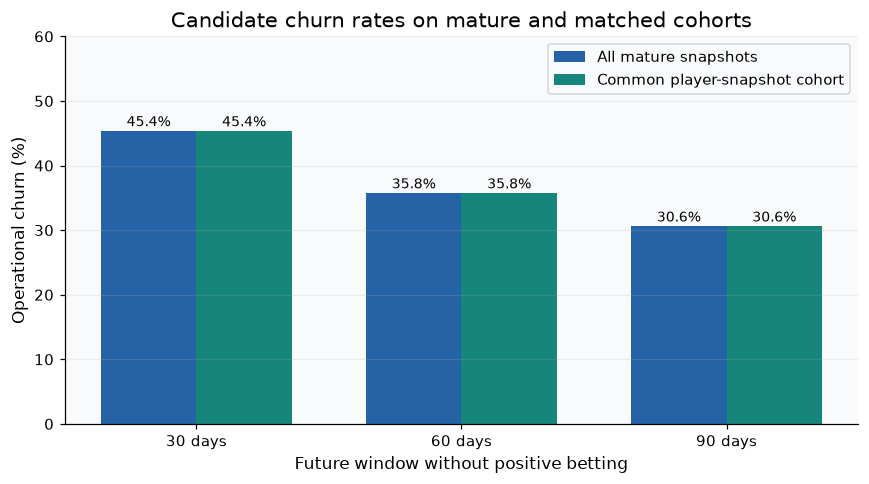

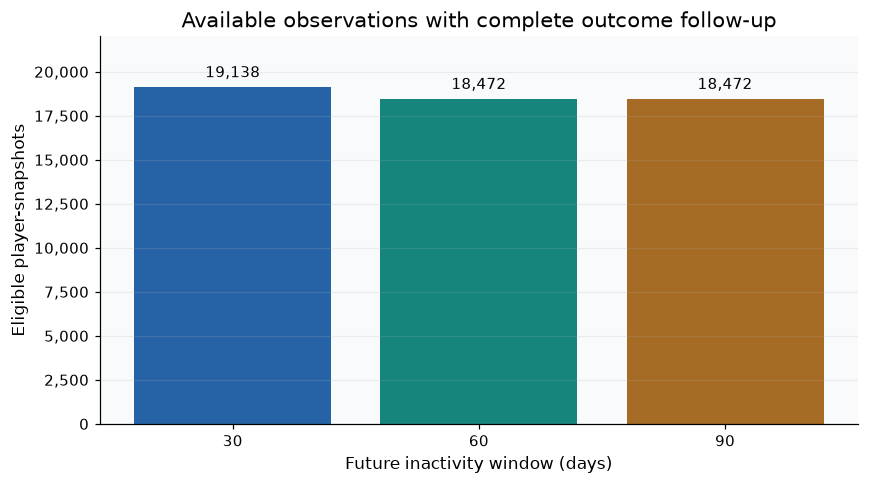

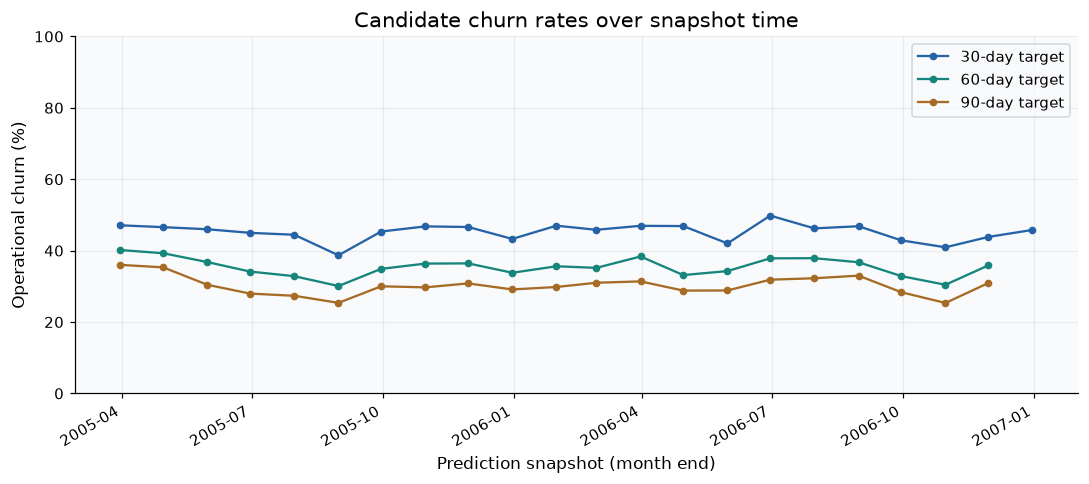

In [4]:
summary_rows = []
for threshold in THRESHOLDS:
    col = f'churn_{threshold}d'
    panel = candidate_panel.loc[candidate_panel[col].notna()]
    summary_rows.append({'threshold_days': threshold, 'eligible_observations': len(panel),
        'unique_players': panel.UserID.nunique(), 'churn_count': int(panel[col].sum()),
        'non_churn_count': int(panel[col].eq(0).sum()), 'churn_pct': float(panel[col].mean()*100),
        'snapshots_available': panel.snapshot.nunique(), 'first_snapshot': panel.snapshot.min(),
        'last_snapshot': panel.snapshot.max()})
candidate_summary = pd.DataFrame(summary_rows).set_index('threshold_days')
label_cols = [f'churn_{d}d' for d in THRESHOLDS]
common_panel = candidate_panel.dropna(subset=label_cols).copy()
common_summary = pd.DataFrame([{'threshold_days': d, 'observations': len(common_panel),
    'unique_players': common_panel.UserID.nunique(),
    'churn_count': int(common_panel[f'churn_{d}d'].sum()),
    'churn_pct': float(common_panel[f'churn_{d}d'].mean()*100)} for d in THRESHOLDS]).set_index('threshold_days')
display(candidate_summary)
print('Common player-snapshot cohort for all three targets:')
display(common_summary)
monthly_rows = []
for threshold in THRESHOLDS:
    col = f'churn_{threshold}d'
    for snapshot, group in candidate_panel.loc[candidate_panel[col].notna()].groupby('snapshot'):
        monthly_rows.append({'threshold_days': threshold, 'snapshot': snapshot,
            'eligible_observations': len(group), 'churn_count': int(group[col].sum()),
            'churn_pct': float(group[col].mean()*100)})
monthly_rates = pd.DataFrame(monthly_rows)
display(monthly_rates)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(3)
ax.bar(x-.18, candidate_summary.churn_pct, width=.36, color='#2563a6', label='All mature snapshots')
ax.bar(x+.18, common_summary.churn_pct, width=.36, color='#16857b', label='Common player-snapshot cohort')
for offset, rates in [(-.18, candidate_summary.churn_pct), (.18, common_summary.churn_pct)]:
    for pos, rate in zip(x+offset, rates): ax.text(pos, rate+.7, f'{rate:.1f}%', ha='center', fontsize=9)
ax.set(xticks=x, xticklabels=['30 days', '60 days', '90 days'], ylim=(0,60),
       xlabel='Future window without positive betting', ylabel='Operational churn (%)',
       title='Candidate churn rates on mature and matched cohorts')
ax.legend(); ax.grid(axis='y', alpha=.2)
fig.tight_layout(); save_show(fig, 'candidate_churn_rates.png')

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar([str(d) for d in THRESHOLDS], candidate_summary.eligible_observations,
              color=[COLORS[d] for d in THRESHOLDS])
ax.bar_label(bars, labels=[f'{v:,}' for v in candidate_summary.eligible_observations], padding=4)
ax.set(ylim=(0, candidate_summary.eligible_observations.max()*1.15),
       xlabel='Future inactivity window (days)', ylabel='Eligible player-snapshots',
       title='Available observations with complete outcome follow-up')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v:,.0f}'))
ax.grid(axis='y', alpha=.2)
fig.tight_layout(); save_show(fig, 'eligible_observations_by_churn_threshold.png')

fig, ax = plt.subplots(figsize=(10, 4.5))
for threshold in THRESHOLDS:
    frame = monthly_rates.loc[monthly_rates.threshold_days.eq(threshold)]
    ax.plot(frame.snapshot, frame.churn_pct, color=COLORS[threshold], marker='o',
            markersize=4, label=f'{threshold}-day target')
ax.set(xlabel='Prediction snapshot (month end)', ylabel='Operational churn (%)',
       title='Candidate churn rates over snapshot time', ylim=(0,100))
ax.legend(); ax.grid(alpha=.2); fig.autofmt_xdate()
fig.tight_layout(); save_show(fig, 'churn_rates_over_snapshot_time.png')
r60, r90 = candidate_summary.loc[60], candidate_summary.loc[90]
section_notes['candidates'] = f"""**Interpretation.** The 60-day candidate has
{r60.eligible_observations:,.0f} player-snapshots from {r60.unique_players:,.0f} players,
{r60.churn_count:,.0f} churn labels and {r60.non_churn_count:,.0f} non-churn labels
({r60.churn_pct:.1f}% churn), across {r60.snapshots_available:.0f} snapshots.
On the shared cohort, churn rates for 30/60/90 days are
{'/'.join(f'{v:.1f}%' for v in common_summary.churn_pct)}.
The 60- and 90-day candidates have the same sample size and last month-end here:
{r60.last_snapshot.date()}. Their latest allowed snapshot days differ, but month-end
scheduling rounds both back to November. A sample-size advantage for 60 versus 90 days
is therefore **not** supported by these data. Rate changes over time describe changing
recently-active cohorts, not platform-wide customer loss or proven seasonality."""

**Interpretation.** The 60-day candidate has
18,472 player-snapshots from 4,025 players,
6,607 churn labels and 11,865 non-churn labels
(35.8% churn), across 21 snapshots.
On the shared cohort, churn rates for 30/60/90 days are
45.4%/35.8%/30.6%.
The 60- and 90-day candidates have the same sample size and last month-end here:
2006-11-30. Their latest allowed snapshot days differ, but month-end
scheduling rounds both back to November. A sample-size advantage for 60 versus 90 days
is therefore **not** supported by these data. Rate changes over time describe changing
recently-active cohorts, not platform-wide customer loss or proven seasonality.

## 4. Label overlap on valid comparisons
Compare labels only where both outcomes are fully observed. Longer inactivity outcomes
are nested: `churn_90d = 1` implies `churn_60d = 1`, which implies `churn_30d = 1`.
A 30-day churn label followed by a 60-day non-churn label means the player resumed
positive betting on days 31–60 after that snapshot. Counts are shown both as
player-snapshots and distinct players; repeated observations must not be called
distinct customers. Agreement uses all comparable pairs; reversal rate uses only
the shorter-window churn cases.

In [5]:
overlap_rows = []
confusion_tables = {}
for shorter, longer in [(30, 60), (60, 90), (30, 90)]:
    sc, lc = f'churn_{shorter}d', f'churn_{longer}d'
    paired = candidate_panel.dropna(subset=[sc, lc])
    reversed_label = paired[sc].eq(1) & paired[lc].eq(0)
    assert not (paired[sc].eq(0) & paired[lc].eq(1)).any(), 'Nested outcomes violated'
    confusion = pd.crosstab(paired[sc], paired[lc]).reindex(index=[0,1], columns=[0,1], fill_value=0)
    confusion_tables[(shorter, longer)] = confusion
    overlap_rows.append({'comparison': f'{shorter}d vs {longer}d',
        'comparable_observations': len(paired), 'unique_players': paired.UserID.nunique(),
        'short_churn_count': int(paired[sc].eq(1).sum()),
        'short_churn_long_nonchurn': int(reversed_label.sum()),
        'unique_players_with_reversal': paired.loc[reversed_label, 'UserID'].nunique(),
        'reversal_pct_of_short_churn': float(reversed_label.sum()/paired[sc].eq(1).sum()*100),
        'agreement_pct': float(paired[sc].eq(paired[lc]).mean()*100)})
    print(f'{shorter}d rows / {longer}d columns: 0 = active in future, 1 = inactive')
    display(confusion)
overlap_summary = pd.DataFrame(overlap_rows).set_index('comparison')
display(overlap_summary)
o3060, o6090 = overlap_summary.loc['30d vs 60d'], overlap_summary.loc['60d vs 90d']
section_notes['overlap'] = f"""**Interpretation.** Of comparable 30-day churn observations,
{o3060.short_churn_long_nonchurn:,.0f} ({o3060.reversal_pct_of_short_churn:.1f}%) become
60-day non-churn because betting resumes on days 31–60; these involve
{o3060.unique_players_with_reversal:,.0f} distinct players. For 60 versus 90 days,
{o6090.short_churn_long_nonchurn:,.0f} observations
({o6090.reversal_pct_of_short_churn:.1f}% of 60-day churn) resume on days 61–90,
involving {o6090.unique_players_with_reversal:,.0f} distinct players.
Agreement is {o3060.agreement_pct:.1f}% for 30/60 and {o6090.agreement_pct:.1f}% for 60/90.
All nested-label checks pass. Differences quantify temporary inactivity relative to
a longer future window; they do not prove either target is wrong for an operational use."""

30d rows / 60d columns: 0 = active in future, 1 = inactive


churn_60d,0,1
churn_30d,,
0,10089,0
1,1776,6607


60d rows / 90d columns: 0 = active in future, 1 = inactive


churn_90d,0,1
churn_60d,,
0,11865,0
1,949,5658


30d rows / 90d columns: 0 = active in future, 1 = inactive


churn_90d,0,1
churn_30d,,
0,10089,0
1,2725,5658


,comparable_observations,unique_players,short_churn_count,short_churn_long_nonchurn,unique_players_with_reversal,reversal_pct_of_short_churn,agreement_pct
comparison,,,,,,,
30d vs 60d,18472,4025,8383,1776,1219,21.186,90.385
60d vs 90d,18472,4025,6607,949,786,14.364,94.862
30d vs 90d,18472,4025,8383,2725,1666,32.506,85.248


**Interpretation.** Of comparable 30-day churn observations,
1,776 (21.2%) become
60-day non-churn because betting resumes on days 31–60; these involve
1,219 distinct players. For 60 versus 90 days,
949 observations
(14.4% of 60-day churn) resume on days 61–90,
involving 786 distinct players.
Agreement is 90.4% for 30/60 and 94.9% for 60/90.
All nested-label checks pass. Differences quantify temporary inactivity relative to
a longer future window; they do not prove either target is wrong for an operational use.

## 5. Reactivation after operational churn, with strict follow-up
For each candidate D and extra horizon H = 30, 60, 90:

- Keep only `churn_Dd = 1` observations with **S + D + H ≤ dataset end**.
- Reactivation means positive Bets within **[S + D + 1, S + D + H]**.
- Denominator: churn-labelled player-snapshots with that whole extra window observed.
- Numerator: those observations with at least one positive-bet return in the extra window.

No absent return in incomplete follow-up is counted as non-reactivation. Show eligible,
excluded, and returning counts and unique players. The denominators differ across H,
so rates across horizons are not a survival curve. Also calculate a comparison using
the same snapshots for all candidates at each H (`S + 90 + H ≤ end`). Its churn subsets
still differ by definition. Overlapping outcomes and repeat players cause dependence;
these are descriptive rates, not independent-event confidence estimates.

all_candidate_churn_observations  \
threshold_days extra_followup_days                                     
30             30                                               8688   
               60                                               8688   
               90                                               8688   
60             30                                               6607   
               60                                               6607   
               90                                               6607   
90             30                                               5658   
               60                                               5658   
               90                                               5658   

                                    eligible_churn_observations  \
threshold_days extra_followup_days                                
30             30                                          8383   
               60                                          8383   
               90                                          8081   
60             30                                          6607   
               60                                          6360   
               90                                          6157   
90             30                                          5445   
               60                                          5276   
               90                                          5075   

                                    excluded_incomplete_followup  \
threshold_days extra_followup_days                                 
30             30                                            305   
               60                                            305   
               90                                            607   
60             30                                              0   
               60                                            247   
               90                                            450   
90             30                                            213   
               60                                            382   
               90                                            583   

                                    unique_eligible_players  \
threshold_days extra_followup_days                            
30             30                                      3875   
               60                                      3875   
               90                                      3824   
60             30                                      3774   
               60                                      3709   
               90                                      3657   
90             30                                      3611   
               60                                      3558   
               90                                      3493   

                                    reactivated_observations  \
threshold_days extra_followup_days                             
30             30                                       1776   
               60                                       2725   
               90                                       3300   
60             30                                        949   
               60                                       1579   
               90                                       2061   
90             30                                        664   
               60                                       1180   
               90                                       1487   

                                    unique_reactivated_players  \
threshold_days extra_followup_days                               
30             30                                         1219   
               60                                         1666   
               90                                         1897   
60             30          

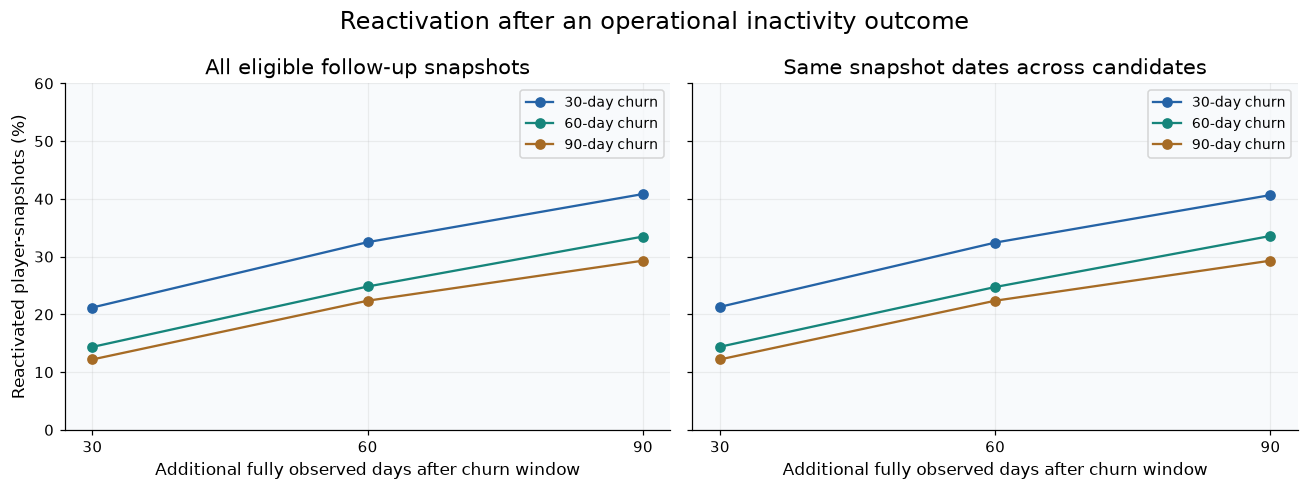

In [6]:
reactivation_rows = []
for threshold in THRESHOLDS:
    churn_panel = candidate_panel.loc[candidate_panel[f'churn_{threshold}d'].eq(1)].copy()
    for horizon in FOLLOWUP_DAYS:
        full_followup = churn_panel.snapshot + pd.Timedelta(days=threshold+horizon) <= study_end
        eligible = churn_panel.loc[full_followup].copy()
        eligible['reactivated'] = False
        for snapshot, group in eligible.groupby('snapshot'):
            return_ids = positive_ids_between(daily,
                snapshot+pd.Timedelta(days=threshold+1),
                snapshot+pd.Timedelta(days=threshold+horizon))
            eligible.loc[group.index, 'reactivated'] = group.UserID.isin(return_ids)
        matched = eligible.loc[eligible.snapshot + pd.Timedelta(days=90+horizon) <= study_end]
        reactivation_rows.append({'threshold_days': threshold, 'extra_followup_days': horizon,
            'all_candidate_churn_observations': len(churn_panel),
            'eligible_churn_observations': len(eligible),
            'excluded_incomplete_followup': int((~full_followup).sum()),
            'unique_eligible_players': eligible.UserID.nunique(),
            'reactivated_observations': int(eligible.reactivated.sum()),
            'unique_reactivated_players': eligible.loc[eligible.reactivated, 'UserID'].nunique(),
            'reactivation_pct': eligible.reactivated.mean()*100,
            'first_snapshot': eligible.snapshot.min(), 'last_snapshot': eligible.snapshot.max(),
            'matched_calendar_churn_observations': len(matched),
            'matched_calendar_reactivations': int(matched.reactivated.sum()),
            'matched_calendar_reactivation_pct': matched.reactivated.mean()*100})
reactivation_summary = pd.DataFrame(reactivation_rows).set_index(['threshold_days', 'extra_followup_days'])
display(reactivation_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for threshold in THRESHOLDS:
    frame = reactivation_summary.loc[threshold]
    axes[0].plot(frame.index, frame.reactivation_pct, marker='o', color=COLORS[threshold], label=f'{threshold}-day churn')
    axes[1].plot(frame.index, frame.matched_calendar_reactivation_pct, marker='o', color=COLORS[threshold], label=f'{threshold}-day churn')
for ax in axes:
    ax.set(xticks=FOLLOWUP_DAYS, xlabel='Additional fully observed days after churn window', ylim=(0,60))
    ax.grid(alpha=.2); ax.legend(fontsize=9)
axes[0].set(title='All eligible follow-up snapshots', ylabel='Reactivated player-snapshots (%)')
axes[1].set(title='Same snapshot dates across candidates')
fig.suptitle('Reactivation after an operational inactivity outcome', fontsize=16)
fig.tight_layout(); save_show(fig, 'reactivation_after_operational_churn.png')

r6030, r6060, r6090 = [reactivation_summary.loc[(60,h)] for h in FOLLOWUP_DAYS]
matched90 = reactivation_summary.xs(90, level='extra_followup_days')
section_notes['reactivation'] = f"""**Interpretation.** Following a completed 60-day inactivity outcome,
reactivation within a further 30/60/90 days is
{r6030.reactivation_pct:.1f}% / {r6060.reactivation_pct:.1f}% / {r6090.reactivation_pct:.1f}%,
with denominators {r6030.eligible_churn_observations:,.0f} /
{r6060.eligible_churn_observations:,.0f} / {r6090.eligible_churn_observations:,.0f} churn
player-snapshots. The 90-day calculation excludes
{r6090.excluded_incomplete_followup:,.0f} 60-day churn observations for incomplete extra follow-up.
On the matched-calendar comparison, 90-extra-day reactivation for 30/60/90-day targets is
{'/'.join(f'{v:.1f}%' for v in matched90.matched_calendar_reactivation_pct)}.
Reactivation remains material even for 90-day operational churn. The longer target
reduces, but does not eliminate, the chance of flagging a temporary pause.
These are conditional player-snapshot rates and are different from Day 3's
distinct-player ever-return shares."""

**Interpretation.** Following a completed 60-day inactivity outcome,
reactivation within a further 30/60/90 days is
14.4% / 24.8% / 33.5%,
with denominators 6,607 /
6,360 / 6,157 churn
player-snapshots. The 90-day calculation excludes
450 60-day churn observations for incomplete extra follow-up.
On the matched-calendar comparison, 90-extra-day reactivation for 30/60/90-day targets is
40.7%/33.6%/29.3%.
Reactivation remains material even for 90-day operational churn. The longer target
reduces, but does not eliminate, the chance of flagging a temporary pause.
These are conditional player-snapshot rates and are different from Day 3's
distinct-player ever-return shares.

## 6. Proposed target and modelling implications
Evaluate behaviour, temporary-inactivity risk, intervention timing, sample availability,
and follow-up maturity together. Class balance is descriptive and is not the selection
criterion. A business decision about how costly it is to contact temporary returners
remains to be validated; the dataset alone cannot optimise intervention economics.

In [7]:
limitations = {
    30: 'More temporary pauses flagged; 21.2% of comparable churn resumes by day 60.',
    60: 'Extended inactivity still permits reactivation; intervention horizon is 60 days.',
    90: '30 extra days to confirm inactivity; same sample size as 60d on this calendar.'}
decision_rows = []
for threshold in THRESHOLDS:
    c = candidate_summary.loc[threshold]
    r = reactivation_summary.loc[(threshold,90)]
    decision_rows.append({'Threshold': f'{threshold} days',
        'Eligible observations': int(c.eligible_observations),
        'Unique players': int(c.unique_players), 'Churn %': round(c.churn_pct, 2),
        'Reactivation evidence': f'{int(r.reactivated_observations):,}/{int(r.eligible_churn_observations):,} '
            f'({r.reactivation_pct:.1f}%) within a further 90 days',
        'Main limitation': limitations[threshold]})
decision_summary = pd.DataFrame(decision_rows)
display(decision_summary)

recommended_threshold = 60
proposed_target = ('Operational churn is defined as no positive betting activity (Bets > 0) '
                   'during the 60 days immediately following a prediction snapshot.')
target_qualification = ('This represents extended inactivity rather than guaranteed permanent '
                        'customer departure; reactivation remains possible.')
r = candidate_summary.loc[recommended_threshold]
section_notes['decision'] = f"""**Recommendation: retain 60 days as a provisional operational target.**

> {proposed_target}

> {target_qualification}

**Why 60 rather than 30:** the positive-betting completed inactivity P95 is 60 full days,
and {o3060.reversal_pct_of_short_churn:.1f}% of comparable 30-day churn observations
resume by day 60. Moving to 60 days materially reduces short-pause classifications.
The completed-gap P95 is supporting evidence only, because it describes returners.

**Why 60 rather than 90:** going to 90 days removes a further
{o6090.reversal_pct_of_short_churn:.1f}% of 60-day churn labels, while the incremental
confirmation period is 30 days. Matched-calendar reactivation within a further 90 days
is {matched90.loc[60, 'matched_calendar_reactivation_pct']:.1f}% for 60-day churn versus
{matched90.loc[90, 'matched_calendar_reactivation_pct']:.1f}% for 90-day churn.
This suggests diminishing returns to waiting longer, not a proof of an optimal threshold.
Both candidates have the same sample size on this month-end calendar. The provisional
preference assumes a retention workflow values a 60-day risk horizon over a 90-day one;
if avoiding temporary-returner contacts is more important, 90 days remains defensible.
Predictions would be made at S; no actual intervention has been designed or evaluated.
Class balance is not the rationale.

**Modelling contract (not yet implemented):**

- Feature observation window remains exactly 30 calendar days, [S−29, S].
- First valid 60-day snapshot: **{r.first_snapshot.date()}**.
- Last valid 60-day snapshot: **{r.last_snapshot.date()}**; its outcome ends
  **{(r.last_snapshot+pd.Timedelta(days=60)).date()}**.
- Expected raw modelling panel: **{r.eligible_observations:,.0f} player-snapshots** from
  **{r.unique_players:,.0f} distinct players**, across **{r.snapshots_available:.0f} snapshots**,
  with **{r.churn_count:,.0f} churn** and **{r.non_churn_count:,.0f} non-churn** observations.
  This is before any future split-boundary purging, not a final training-set size.
- All features must use only historical data through S. Future activity is used only
  for labels and retrospective reactivation diagnostics, never for features or eligibility.
- Global coverage is assumed complete through the dataset end. Absence is operational
  inactivity in this dataset, not proof of permanent departure or platform account closure.
- No label is generated from a partial future window. Reactivation requires its own
  complete additional window; near-end churn cases are excluded only from those diagnostics.
- Monthly snapshots repeat customers and have overlapping 60-day outcomes. A future
  temporal evaluation should purge training snapshots whose outcome windows cross a
  validation/test prediction boundary. Random row splits would mix time and customers;
  decide whether evaluation targets future behaviour of known players or unseen players.
- History/activity eligibility excludes inactive customers and some late/brief activity;
  this target applies to recently gambling players, not the entire registration cohort.

No final ML dataset, predictive feature table, or model is saved."""
assert {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in inputs} == input_hashes
assert all((FIGURE_DIR / name).stat().st_size > 0 for name in saved_figures)
print('Recommended provisional threshold:', recommended_threshold)
print(proposed_target)
print(target_qualification)
print(f'{len(saved_figures)} figures saved; cleaned CSV hashes unchanged.')
display(pd.DataFrame({'saved_figure': saved_figures}))

,Threshold,Eligible observations,Unique players,Churn %,Reactivation evidence,Main limitation
0,30 days,19138,4059,45.40,"3,300/8,081 (40.8%) within a further 90 days",More temporary pauses flagged; 21.2% of compar...
1,60 days,18472,4025,35.77,"2,061/6,157 (33.5%) within a further 90 days",Extended inactivity still permits reactivation...
2,90 days,18472,4025,30.63,"1,487/5,075 (29.3%) within a further 90 days",30 extra days to confirm inactivity; same samp...


Recommended provisional threshold: 60
Operational churn is defined as no positive betting activity (Bets > 0) during the 60 days immediately following a prediction snapshot.
This represents extended inactivity rather than guaranteed permanent customer departure; reactivation remains possible.
4 figures saved; cleaned CSV hashes unchanged.


,saved_figure
0,candidate_churn_rates.png
1,eligible_observations_by_churn_threshold.png
2,churn_rates_over_snapshot_time.png
3,reactivation_after_operational_churn.png


**Recommendation: retain 60 days as a provisional operational target.**

> Operational churn is defined as no positive betting activity (Bets > 0) during the 60 days immediately following a prediction snapshot.

> This represents extended inactivity rather than guaranteed permanent customer departure; reactivation remains possible.

**Why 60 rather than 30:** the positive-betting completed inactivity P95 is 60 full days,
and 21.2% of comparable 30-day churn observations
resume by day 60. Moving to 60 days materially reduces short-pause classifications.
The completed-gap P95 is supporting evidence only, because it describes returners.

**Why 60 rather than 90:** going to 90 days removes a further
14.4% of 60-day churn labels, while the incremental
confirmation period is 30 days. Matched-calendar reactivation within a further 90 days
is 33.6% for 60-day churn versus
29.3% for 90-day churn.
This suggests diminishing returns to waiting longer, not a proof of an optimal threshold.
Both candidates have the same sample size on this month-end calendar. The provisional
preference assumes a retention workflow values a 60-day risk horizon over a 90-day one;
if avoiding temporary-returner contacts is more important, 90 days remains defensible.
Predictions would be made at S; no actual intervention has been designed or evaluated.
Class balance is not the rationale.

**Modelling contract (not yet implemented):**

- Feature observation window remains exactly 30 calendar days, [S−29, S].
- First valid 60-day snapshot: **2005-03-31**.
- Last valid 60-day snapshot: **2006-11-30**; its outcome ends
  **2007-01-29**.
- Expected raw modelling panel: **18,472 player-snapshots** from
  **4,025 distinct players**, across **21 snapshots**,
  with **6,607 churn** and **11,865 non-churn** observations.
  This is before any future split-boundary purging, not a final training-set size.
- All features must use only historical data through S. Future activity is used only
  for labels and retrospective reactivation diagnostics, never for features or eligibility.
- Global coverage is assumed complete through the dataset end. Absence is operational
  inactivity in this dataset, not proof of permanent departure or platform account closure.
- No label is generated from a partial future window. Reactivation requires its own
  complete additional window; near-end churn cases are excluded only from those diagnostics.
- Monthly snapshots repeat customers and have overlapping 60-day outcomes. A future
  temporal evaluation should purge training snapshots whose outcome windows cross a
  validation/test prediction boundary. Random row splits would mix time and customers;
  decide whether evaluation targets future behaviour of known players or unseen players.
- History/activity eligibility excludes inactive customers and some late/brief activity;
  this target applies to recently gambling players, not the entire registration cohort.

No final ML dataset, predictive feature table, or model is saved.